# Week 6, Phase 2 â€” GP observation-treatment comparison

## 1. Scope

This notebook explains the complete 241-simulation comparison of
three observation treatments for melt-pool width, length, and
penetration depth. The covariance family is fixed to
`ConstantKernel Ã— isotropic MatÃ©rn 3/2`, so observed differences
can be attributed to how the simulation-level targets are treated.

No new kernel family, ARD, feature-effect analysis, active
learning, level-set estimation, classifier, or new label analysis
is performed.

Rebuild command:

```powershell
.\.venv\Scripts\python.exe src\week6_phase2_gp_response_noise_comparison.py --full --force --workers 4
```

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

START = Path.cwd().resolve()
ROOT = next(
    (
        candidate
        for candidate in (START, *START.parents)
        if (
            candidate
            / "outputs"
            / "week6_02_gp_response_noise_comparison"
        ).is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "Could not locate the repository from the notebook "
        "working directory."
    )
OUT = ROOT / "outputs" / "week6_02_gp_response_noise_comparison"
PHASE1 = (
    ROOT
    / "outputs"
    / "week6_01_melt_pool_data_audit"
    / "week6_phase1_simulation_level_responses.csv"
)
config = json.loads(
    (OUT / "phase2_model_configuration.json").read_text(
        encoding="utf-8"
    )
)
summary = json.loads(
    (OUT / "summary.json").read_text(encoding="utf-8")
)
pd.Series({
    "Phase 1 rows": summary["phase1_rows"],
    "immutable revision": summary["phase1_revision"],
    "features": summary["features"],
    "targets": list(summary["targets"]),
    "primary LOO models": summary["primary_loo_model_count"],
})

Phase 1 rows                                               241
immutable revision    0e859b748fdbc8454f66e58e101e333ac0479d42
features                                       [P, VX, LS, ST]
targets                                 [width, length, depth]
primary LOO models                                           9
dtype: object

The source is the corrected Phase 1 ledger at one immutable
Hugging Face revision. The study contains nine primary comparisons:
three responses multiplied by three observation treatments.

## 2. Input and leakage policy

In [2]:
input_table = pd.read_csv(OUT / "phase2_input_target_table.csv")
feature_columns = ["P", "VX", "LS", "ST"]
target_columns = [
    "width_target_um",
    "length_target_um",
    "depth_target_um",
]
checks = pd.Series({
    "241 rows": len(input_table) == 241,
    "unique simulation IDs": input_table["simulation_id"].is_unique,
    "four finite inputs": np.isfinite(
        input_table[feature_columns].to_numpy(float)
    ).all(),
    "three finite positive targets": (
        np.isfinite(
            input_table[target_columns].to_numpy(float)
        ).all()
        and (
            input_table[target_columns].to_numpy(float) > 0
        ).all()
    ),
    "exact feature policy": config["feature_columns"] == feature_columns,
})
display(checks)
assert checks.all()

241 rows                         True
unique simulation IDs            True
four finite inputs               True
three finite positive targets    True
exact feature policy             True
dtype: bool

Only `P`, `VX`, `LS`, and `ST` enter the GP. IDs, timestamps,
window diagnostics, target summaries, flags, provenance, and every
target-derived field are excluded. Flags are used only for the
later sensitivity subset.

## 3. What the three observation treatments mean

In [3]:
pd.DataFrame(config["approaches"]).T[
    ["kernel", "interpretation"]
]

,kernel,interpretation
A_tiny_jitter,ConstantKernel * Matern(nu=1.5),fixed numerical stabilization only
B_learned_nugget,ConstantKernel * Matern(nu=1.5) + WhiteKernel,learned effective nugget; not stochastic simul...
C_heteroskedastic,ConstantKernel * Matern(nu=1.5),observation-specific target-summary uncertaint...


**A â€” tiny jitter:** `alpha=1e-6` in normalized units prevents
numerical singularities. It is not a scientific noise estimate.

**B â€” learned nugget:** WhiteKernel learns one shared effective
discrepancy variance per fold. It can absorb target-summary
variability, unmodelled inputs, fixed-kernel misspecification, and
other residual discrepancy. It does not directly measure the
target-definition error and is not stochastic simulator noise.

**C â€” observation-specific alpha:** each simulation and response
gets its own target-summary uncertainty proxy. Deterministic
simulation does not make a finite-window median exact: the median
can still depend on temporal variation and where the selected
window lies.

## 4. Moving-block bootstrap uncertainty

In [4]:
uncertainty = pd.read_csv(
    OUT / "target_summary_uncertainty_estimates.csv"
)
display(
    uncertainty.groupby("target").agg(
        simulations=("simulation_id", "nunique"),
        median_window_rows=(
            "selected_window_observation_count",
            "median",
        ),
        median_block_length=("block_length", "median"),
        median_std_um=("bootstrap_median_std_um", "median"),
        q95_std_um=(
            "bootstrap_median_std_um",
            lambda x: x.quantile(0.95),
        ),
        maximum_std_um=("bootstrap_median_std_um", "max"),
    )
)
assert len(uncertainty) == 723
assert uncertainty["phase1_target_reproduced"].all()

,simulations,median_window_rows,median_block_length,median_std_um,q95_std_um,maximum_std_um
target,,,,,,
depth,241,13751.0,24.0,0.007625,0.532991,1.997125
length,241,13751.0,24.0,0.219390,0.764620,3.262203
width,241,13751.0,24.0,0.030917,0.264717,2.832068


Each selected window is resampled with contiguous circular blocks,
not independent rows, because adjacent timesteps are temporally
correlated. Five hundred resamples estimate the variance of the
window median. The result describes stability of the chosen target
summary; it is neither measurement error nor simulator randomness.
Different temporal traces naturally produce different alpha values.

In [5]:
block_sensitivity = pd.read_csv(
    OUT / "block_bootstrap_sensitivity.csv"
)
display(
    block_sensitivity[
        [
            "target",
            "variability_class",
            "simulation_id",
            "block_scenario",
            "block_length",
            "bootstrap_median_std_um",
            "std_ratio_to_base",
            "qualitatively_stable_vs_base",
        ]
    ]
)

,target,variability_class,simulation_id,block_scenario,block_length,bootstrap_median_std_um,std_ratio_to_base,qualitatively_stable_vs_base
0,depth,high_variability,sim_00038,base,24,1.965103,1.000000,True
1,depth,high_variability,sim_00038,double,48,2.318949,1.180065,True
2,depth,high_variability,sim_00038,half,12,1.789392,0.910584,True
3,depth,low_variability,sim_00098,base,25,0.001505,1.000000,True
4,depth,low_variability,sim_00098,double,50,0.002139,1.421296,True
5,depth,low_variability,sim_00098,half,12,0.001066,0.708173,True
6,depth,middle_variability,sim_00204,base,23,0.007916,1.000000,True
7,depth,middle_variability,sim_00204,double,46,0.010741,1.356955,True
8,depth,middle_variability,sim_00204,half,12,0.005714,0.721845,True
9,length,high_variability,sim_00154,base,22,3.131657,1.000000,True


Low-, middle-, and high-variability examples were repeated with
half and double block lengths. Ratios show whether the qualitative
magnitude of the uncertainty estimate survives this modelling
choice; disagreement is a limitation, not a reason to silently
tune the block length.

## 5. Fold-local scaling and predictive uncertainty

In [6]:
width_predictions = pd.read_csv(
    OUT / "width_loo_predictions.csv"
)
example = width_predictions.loc[
    width_predictions["method"] == "C_heteroskedastic"
].iloc[0]
variance_um2 = example["heldout_target_summary_variance_um2"]
training_std_um = example["training_y_std_um"]
normalized_variance_example = (
    variance_um2 / training_std_um**2 + 1e-6
)
pd.Series({
    "held-out simulation": example["heldout_simulation_id"],
    "training y std (Âµm)": training_std_um,
    "held-out proxy variance (ÂµmÂ²; oracle only)": variance_um2,
    "illustrative normalized variance + floor": (
        normalized_variance_example
    ),
    "model normalize_y": example["normalize_y"],
    "training rows": example["training_size"],
})

held-out simulation                             sim_00001
training y std (Âµm)                            37.453494
held-out proxy variance (ÂµmÂ²; oracle only)     0.000306
illustrative normalized variance + floor         0.000001
model normalize_y                                   False
training rows                                         240
dtype: object

Every fold fits the X scaler and y mean/standard deviation on its
240 training simulations only. Physical variances must be divided
by the *training-fold* y variance before becoming GP alpha values;
otherwise units are inconsistent and the held-out target can leak
into preprocessing.

The GP's latent interval describes uncertainty about the smooth
underlying response. B's total interval adds its learned shared
nugget. C's retrospective oracle interval adds the held-out
simulation's own target-summary variance. That oracle quantity
would not be known for a truly unseen, not-yet-run simulation, so
it is not a deployable future interval.

## 6. Width LOO results

In [7]:
metrics = pd.read_csv(OUT / "all_model_metrics.csv")
primary = metrics.loc[
    metrics["analysis_label"] == "full_population_loo"
]
width_metrics = primary.loc[
    primary["target"] == "width",
    [
        "method",
        "mae_um",
        "rmse_um",
        "r2",
        "nrmse",
        "mean_nlpd",
        "latent_95_coverage",
        "observation_95_coverage",
        "optimizer_warning_folds",
        "any_bound_hit_folds",
    ],
]
display(width_metrics)

,method,mae_um,rmse_um,r2,nrmse,mean_nlpd,latent_95_coverage,observation_95_coverage,optimizer_warning_folds,any_bound_hit_folds
6,A_tiny_jitter,4.521570,8.037461,0.953908,0.047152,3.742192,0.933610,NaN,0,0
7,B_learned_nugget,3.274485,6.696354,0.968006,0.039284,3.573746,0.875519,0.962656,3,0
8,C_heteroskedastic,4.521434,8.036909,0.953914,0.047149,3.742482,0.933610,0.933610,0,0


Width methods are compared first on held-out point error, then on
predictive density, calibration, optimization stability, and cost.
RÂ² is contextual evidence only and does not determine the choice.

## 7. Length LOO results

In [8]:
length_metrics = primary.loc[
    primary["target"] == "length",
    width_metrics.columns,
]
display(length_metrics)

,method,mae_um,rmse_um,r2,nrmse,mean_nlpd,latent_95_coverage,observation_95_coverage,optimizer_warning_folds,any_bound_hit_folds
3,A_tiny_jitter,15.073950,25.738974,0.919049,0.060199,5.377487,0.933610,NaN,0,0
4,B_learned_nugget,10.622780,19.389062,0.954064,0.045348,4.472070,0.883817,0.954357,1,0
5,C_heteroskedastic,15.045825,25.688167,0.919369,0.060080,5.365146,0.933610,0.933610,0,0


Length uses the identical folds, scalers, kernel bounds, and
optimizer policy. Differences from width therefore concern the
response surface and observation treatment, not a changed model
family.

## 8. Depth LOO results

In [9]:
depth_metrics = primary.loc[
    primary["target"] == "depth",
    width_metrics.columns,
]
display(depth_metrics)

,method,mae_um,rmse_um,r2,nrmse,mean_nlpd,latent_95_coverage,observation_95_coverage,optimizer_warning_folds,any_bound_hit_folds
0,A_tiny_jitter,3.015944,4.955872,0.916913,0.046274,5.199444,0.975104,NaN,1,0
1,B_learned_nugget,2.362253,4.595886,0.928545,0.042913,3.037307,0.925311,0.966805,0,0
2,C_heteroskedastic,2.533052,4.091001,0.943382,0.038199,3.254941,0.929461,0.929461,0,0


Penetration depth is evaluated independently. A treatment need not
win all three responses, and small numerical differences are not
called superior without paired uncertainty evidence.

## 9. Learned nugget and heteroskedastic alpha

In [10]:
nugget = pd.read_csv(OUT / "learned_nugget_summary.csv")
alpha = pd.read_csv(OUT / "heteroskedastic_alpha_summary.csv")
display(nugget)
display(alpha.loc[alpha["subset"] == "all"])

,target,target_label,fold_count,noise_variance_normalized_min,noise_variance_normalized_q25,noise_variance_normalized_median,noise_variance_normalized_q75,noise_variance_normalized_max,noise_std_um_min,noise_std_um_q25,noise_std_um_median,noise_std_um_q75,noise_std_um_max,noise_std_fraction_training_std_min,noise_std_fraction_training_std_median,noise_std_fraction_training_std_max,noise_std_um_coefficient_of_variation_across_folds,noise_bound_hit_folds,optimizer_warning_folds,interpretation
0,width,Melt-pool width,241,0.012452,0.027188,0.027234,0.027342,0.027955,4.185619,6.180752,6.184851,6.186731,6.191019,0.111588,0.165027,0.167199,0.021470,0,3,effective nugget that can absorb target-summar...
1,length,Melt-pool length,241,0.021337,0.031812,0.031908,0.032020,0.032406,13.181611,16.154020,16.170993,16.179339,16.211697,0.146073,0.178629,0.180017,0.015579,0,1,effective nugget that can absorb target-summar...
2,depth,Penetration depth below original surface,241,0.035005,0.048312,0.048443,0.048627,0.049889,3.200421,3.783422,3.787863,3.790808,3.829225,0.187097,0.220098,0.223359,0.014302,0,0,effective nugget that can absorb target-summar...


,target,target_label,subset,simulation_count,variance_um2_min,variance_um2_q25,variance_um2_median,variance_um2_q75,variance_um2_q95,variance_um2_max,std_um_min,std_um_q25,std_um_median,std_um_q75,std_um_q95,std_um_max,zero_variance_count,interpretation
0,width,Melt-pool width,all,241,0.000102,0.00039,0.000956,0.003623,0.070075,8.020612,0.010122,0.019755,0.030917,0.060194,0.264717,2.832068,0,moving-block-bootstrap uncertainty of the sele...
3,length,Melt-pool length,all,241,0.004524,0.01853,0.048132,0.168264,0.584644,10.641970,0.067257,0.136126,0.219390,0.410200,0.764620,3.262203,0,moving-block-bootstrap uncertainty of the sele...
6,depth,Penetration depth below original surface,all,241,0.000002,0.00002,0.000058,0.003020,0.284079,3.988508,0.001498,0.004426,0.007625,0.054953,0.532991,1.997125,0,moving-block-bootstrap uncertainty of the sele...


The learned nugget is reported in normalized variance, normalized
standard deviation, micrometres, and as a fraction of each fold's
training-target standard deviation. Bound hits reveal when the
optimum is weakly identified. Observation-specific alpha summaries
retain the actual between-simulation distribution rather than
collapsing it to one shared value.

## 10. Paired comparisons

In [11]:
paired = pd.read_csv(OUT / "paired_bootstrap_summary.csv")
display(
    paired[
        [
            "target",
            "method_a",
            "method_b",
            "method_b_improved_count",
            "method_b_worsened_count",
            "tied_count",
            "observed_mae_difference_b_minus_a_um",
            "mae_difference_ci95_low_um",
            "mae_difference_ci95_high_um",
            "observed_rmse_difference_b_minus_a_um",
            "rmse_difference_ci95_low_um",
            "rmse_difference_ci95_high_um",
        ]
    ]
)

,target,method_a,method_b,method_b_improved_count,method_b_worsened_count,tied_count,observed_mae_difference_b_minus_a_um,mae_difference_ci95_low_um,mae_difference_ci95_high_um,observed_rmse_difference_b_minus_a_um,rmse_difference_ci95_low_um,rmse_difference_ci95_high_um
0,depth,A_tiny_jitter,B_learned_nugget,148,93,0,-0.653691,-0.988692,-0.321284,-0.359986,-1.364875,0.617602
1,depth,A_tiny_jitter,C_heteroskedastic,137,104,0,-0.482892,-0.715638,-0.261932,-0.864871,-1.338804,-0.410645
2,depth,B_learned_nugget,C_heteroskedastic,105,136,0,0.170799,-0.110038,0.430903,-0.504885,-1.405463,0.381843
3,length,A_tiny_jitter,B_learned_nugget,152,89,0,-4.451169,-5.987643,-3.007102,-6.349913,-9.700995,-3.533900
4,length,A_tiny_jitter,C_heteroskedastic,155,86,0,-0.028125,-0.040663,-0.016787,-0.050808,-0.082908,-0.022346
5,length,B_learned_nugget,C_heteroskedastic,88,153,0,4.423045,3.024319,5.938875,6.299105,3.541326,9.708219
6,width,A_tiny_jitter,B_learned_nugget,141,100,0,-1.247085,-1.774112,-0.759280,-1.341107,-2.733825,-0.403611
7,width,A_tiny_jitter,C_heteroskedastic,141,100,0,-0.000136,-0.000985,0.000802,-0.000553,-0.001356,0.000140
8,width,B_learned_nugget,C_heteroskedastic,100,141,0,1.246949,0.759783,1.780597,1.340554,0.382460,2.761761


Every comparison is paired on the same held-out simulations.
Negative Bâˆ’A differences favor the second method. Ten thousand
paired bootstrap resamples quantify uncertainty in MAE and RMSE
differences. Intervals containing zero do not support a robust
superiority claim.

## 11. Preferred treatment by response

In [12]:
preferences = pd.read_csv(
    OUT / "preferred_method_selection.csv"
)
display(preferences)

,target,preferred_method,selection_strength,rmse_winner,mae_winner,nlpd_winner,rmse_um,mae_um,mean_nlpd,latent_95_coverage,observation_95_coverage,robust_against_other_methods,scientific_interpretation
0,width,B_learned_nugget,robust paired-RMSE advantage,B_learned_nugget,B_learned_nugget,B_learned_nugget,6.696354,3.274485,3.573746,0.875519,0.962656,"{""A_tiny_jitter"":true,""C_heteroskedastic"":true}","Point prediction has first priority. NLPD, cal..."
1,length,B_learned_nugget,robust paired-RMSE advantage,B_learned_nugget,B_learned_nugget,B_learned_nugget,19.389062,10.622780,4.472070,0.883817,0.954357,"{""A_tiny_jitter"":true,""C_heteroskedastic"":true}","Point prediction has first priority. NLPD, cal..."
2,depth,C_heteroskedastic,numerical preference; paired uncertainty overl...,C_heteroskedastic,B_learned_nugget,B_learned_nugget,4.091001,2.533052,3.254941,0.929461,0.929461,"{""A_tiny_jitter"":true,""B_learned_nugget"":false}","Point prediction has first priority. NLPD, cal..."


Selection is response-specific. Held-out point prediction has
priority; NLPD and calibration, optimizer stability,
interpretability, and runtime provide secondary evidence. The
`selection_strength` field distinguishes robust paired evidence
from a merely numerical preference.

## 12. Stable-window sensitivity

In [13]:
stable = pd.read_csv(OUT / "stable_subset_sensitivity.csv")
display(
    stable[
        [
            "target",
            "preferred_method",
            "analysis_label",
            "n_predictions",
            "mae_um",
            "rmse_um",
            "mean_nlpd",
            "unstable_windows_materially_affect_conclusion",
        ]
    ]
)

,target,preferred_method,analysis_label,n_predictions,mae_um,rmse_um,mean_nlpd,unstable_windows_materially_affect_conclusion
0,width,B_learned_nugget,full_241_all_heldouts,241,3.274485,6.696354,3.573746,False
1,width,B_learned_nugget,full_population_model_stable_heldouts_230,230,3.297329,6.810791,3.601590,False
2,width,B_learned_nugget,stable_only_refit_loo_230,230,3.347743,6.839980,3.598809,False
3,length,B_learned_nugget,full_241_all_heldouts,241,10.622780,19.389062,4.472070,False
4,length,B_learned_nugget,full_population_model_stable_heldouts_230,230,10.444653,19.163924,4.472476,False
5,length,B_learned_nugget,stable_only_refit_loo_230,230,10.485932,19.254368,4.479663,False
6,depth,C_heteroskedastic,full_241_all_heldouts,241,2.533052,4.091001,3.254941,True
7,depth,C_heteroskedastic,full_population_model_stable_heldouts_230,230,2.267474,3.517802,2.806032,True
8,depth,C_heteroskedastic,stable_only_refit_loo_230,230,2.076667,3.013798,2.703817,True


The 11 flagged simulations remain in the primary 241-row analysis.
The sensitivity study separately compares the full result, the 230
stable held-outs from that full LOO run, and a new 230-simulation
stable-only LOO refit. A flag denotes temporal target-window
instability, not automatic invalidity.

## 13. Concise model-ready table

In [14]:
model_ready = pd.read_csv(
    OUT / "phase2_model_ready_summary.csv"
)
display(model_ready.head())
print("shape:", model_ready.shape)

,simulation_id,P,VX,LS,ST,selected_width_target_um,selected_length_target_um,selected_depth_target_um,width_target_summary_uncertainty_um,length_target_summary_uncertainty_um,depth_target_summary_uncertainty_um,phase1_unstable_window_flag
0,sim_00001,101.127472,0.523947,0.000045,300.000000,126.261440,262.57085,50.710190,0.017479,0.123066,0.008070,False
1,sim_00002,104.101542,0.916530,0.000088,394.968413,126.328725,297.70070,26.660185,2.832068,0.552649,0.004925,True
2,sim_00003,105.276295,0.639039,0.000077,367.448583,127.941225,261.84470,34.838855,0.020698,0.175755,0.004252,False
3,sim_00004,107.176160,0.320752,0.000088,393.859644,203.322550,288.07835,46.715575,0.158116,0.397009,0.015640,False
4,sim_00005,109.759946,0.241926,0.000045,300.000000,166.993245,236.38403,66.619015,0.010424,0.339606,0.005838,False


shape: (241, 12)


This 12-column table is the compact inspection view: simulation ID,
four inputs, three selected targets, three bootstrap uncertainty
standard deviations, and the Phase 1 instability flag. The
original 199-column Phase 1 audit ledger remains unchanged.

## 14. Focused diagnostics

point_metric_comparison.png


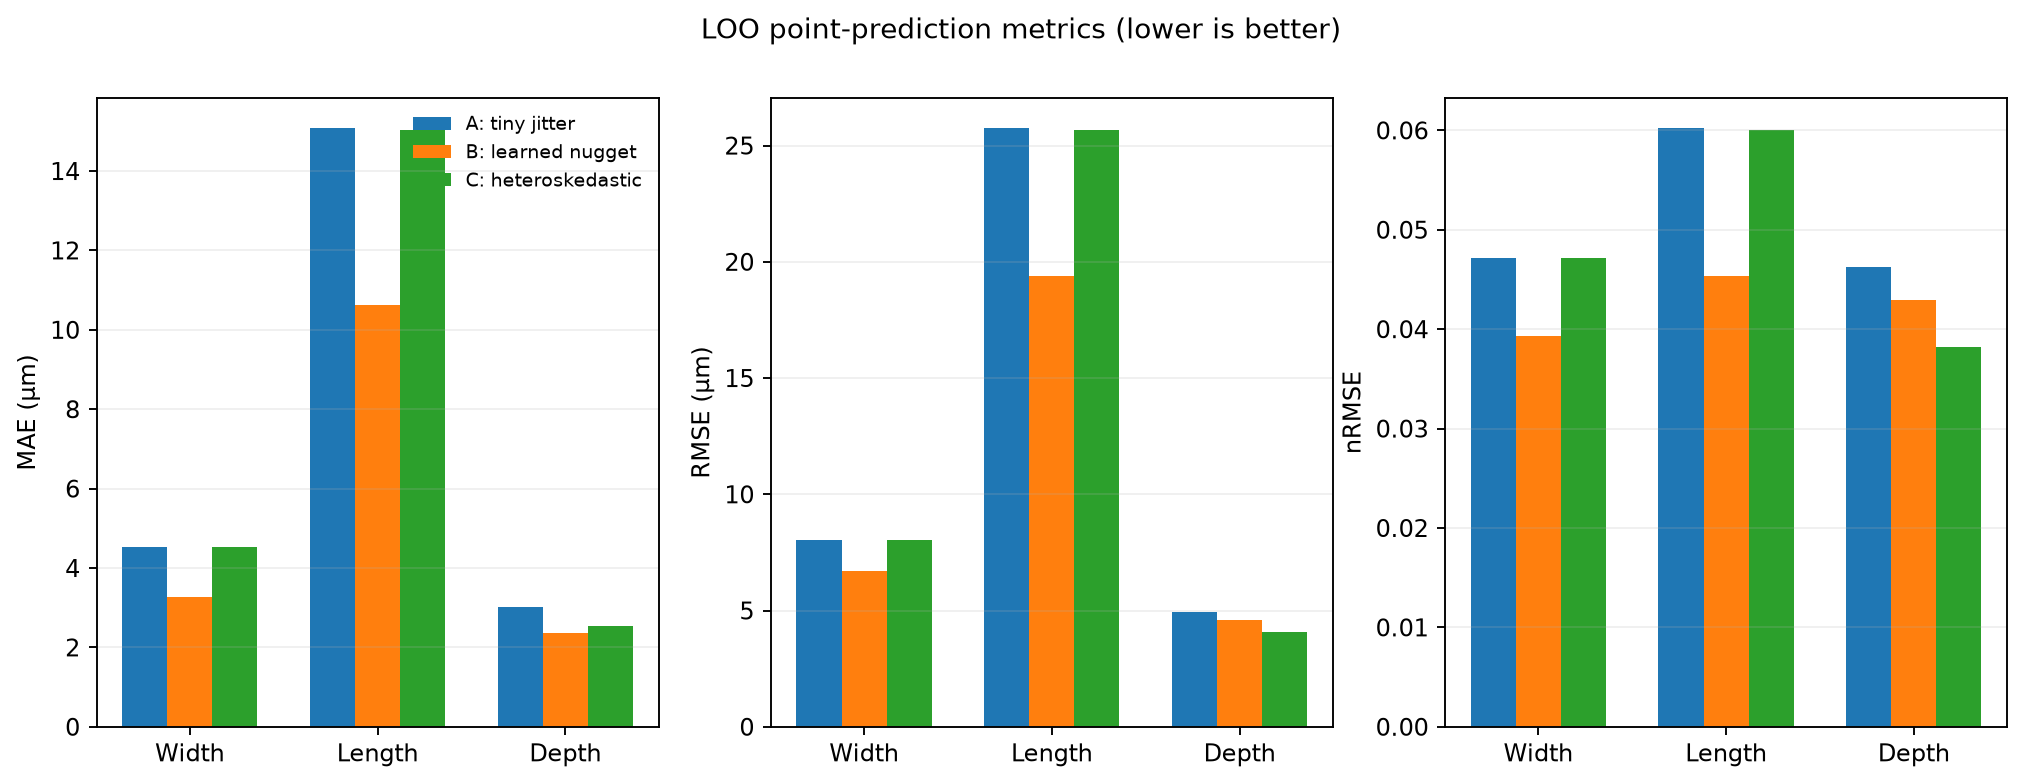

nlpd_and_coverage_comparison.png


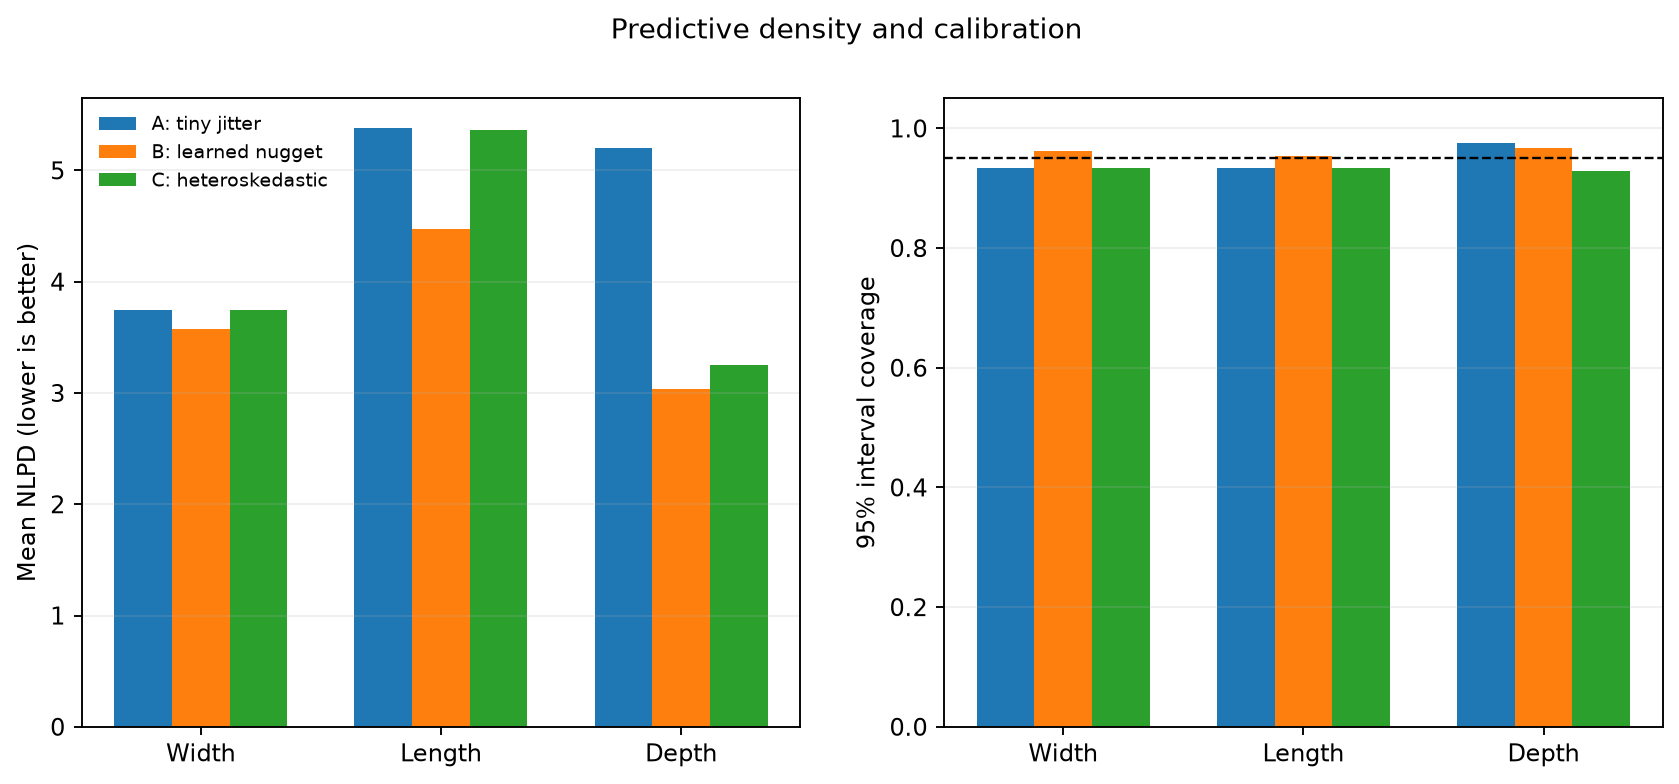

learned_nugget_distributions.png


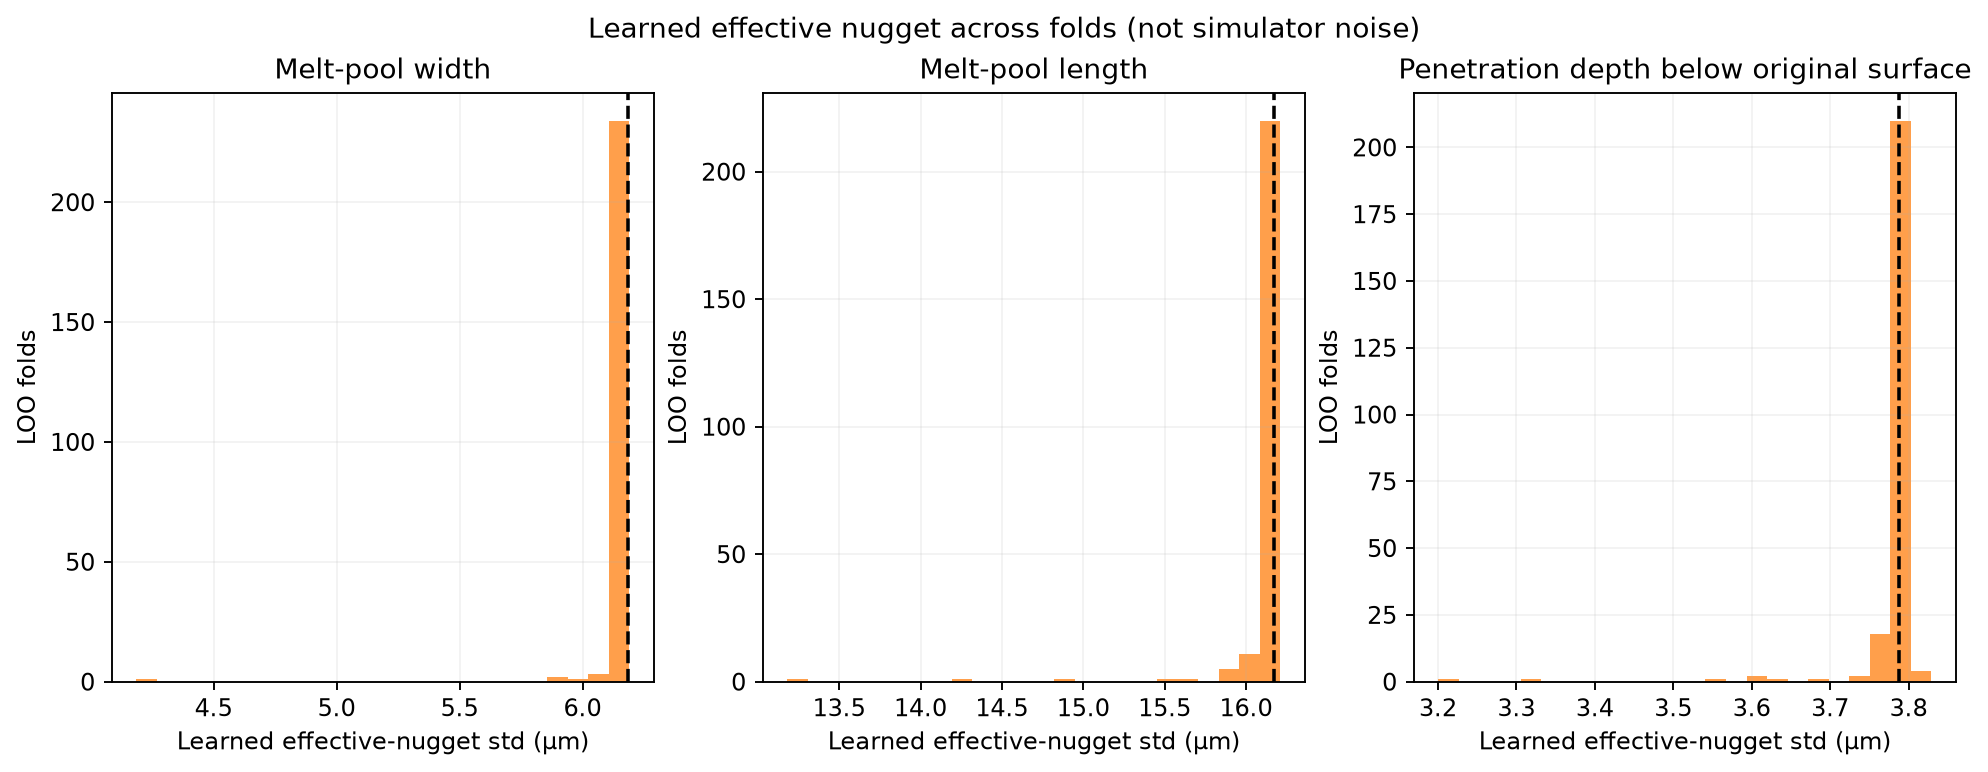

observation_specific_uncertainty_distributions.png


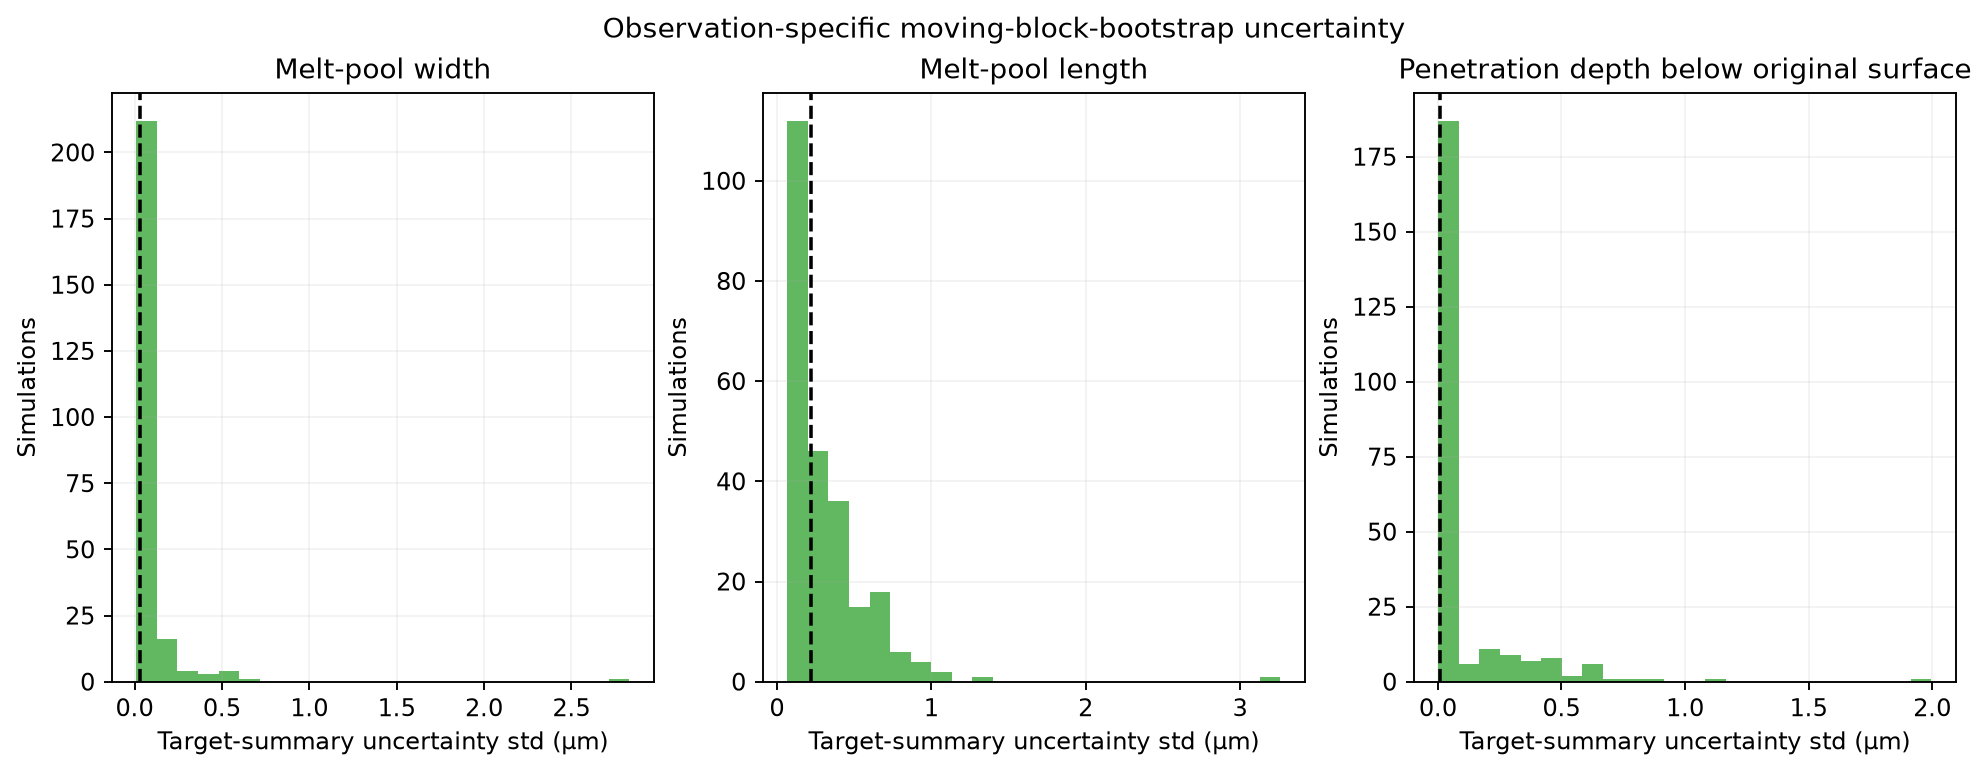

target_uncertainty_vs_unstable_flag.png


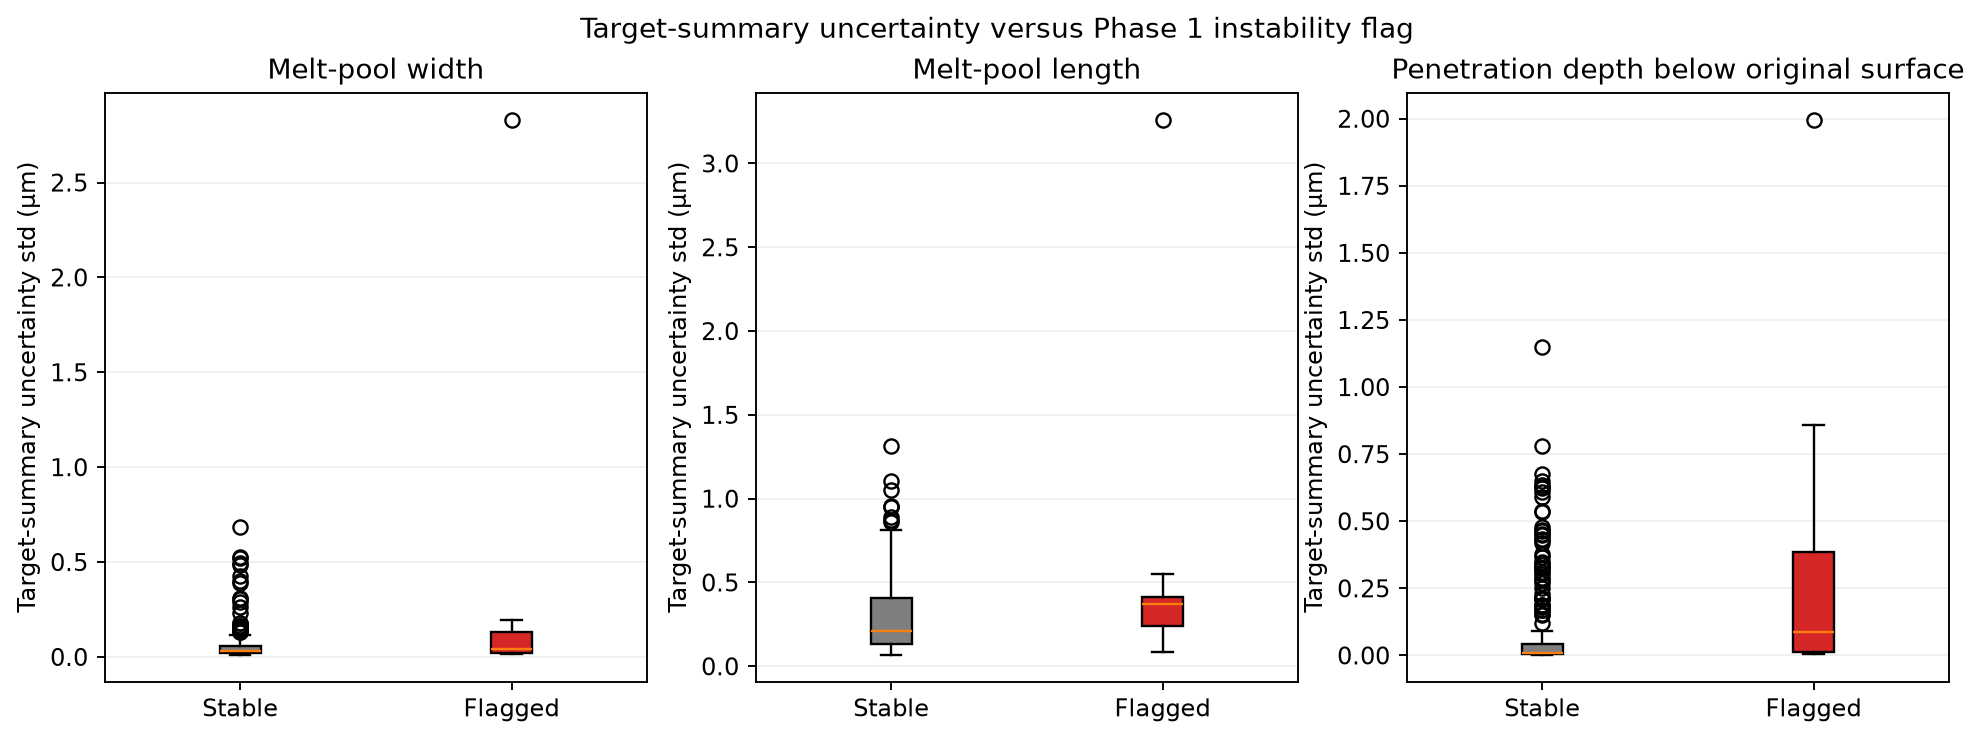

stable_subset_sensitivity.png


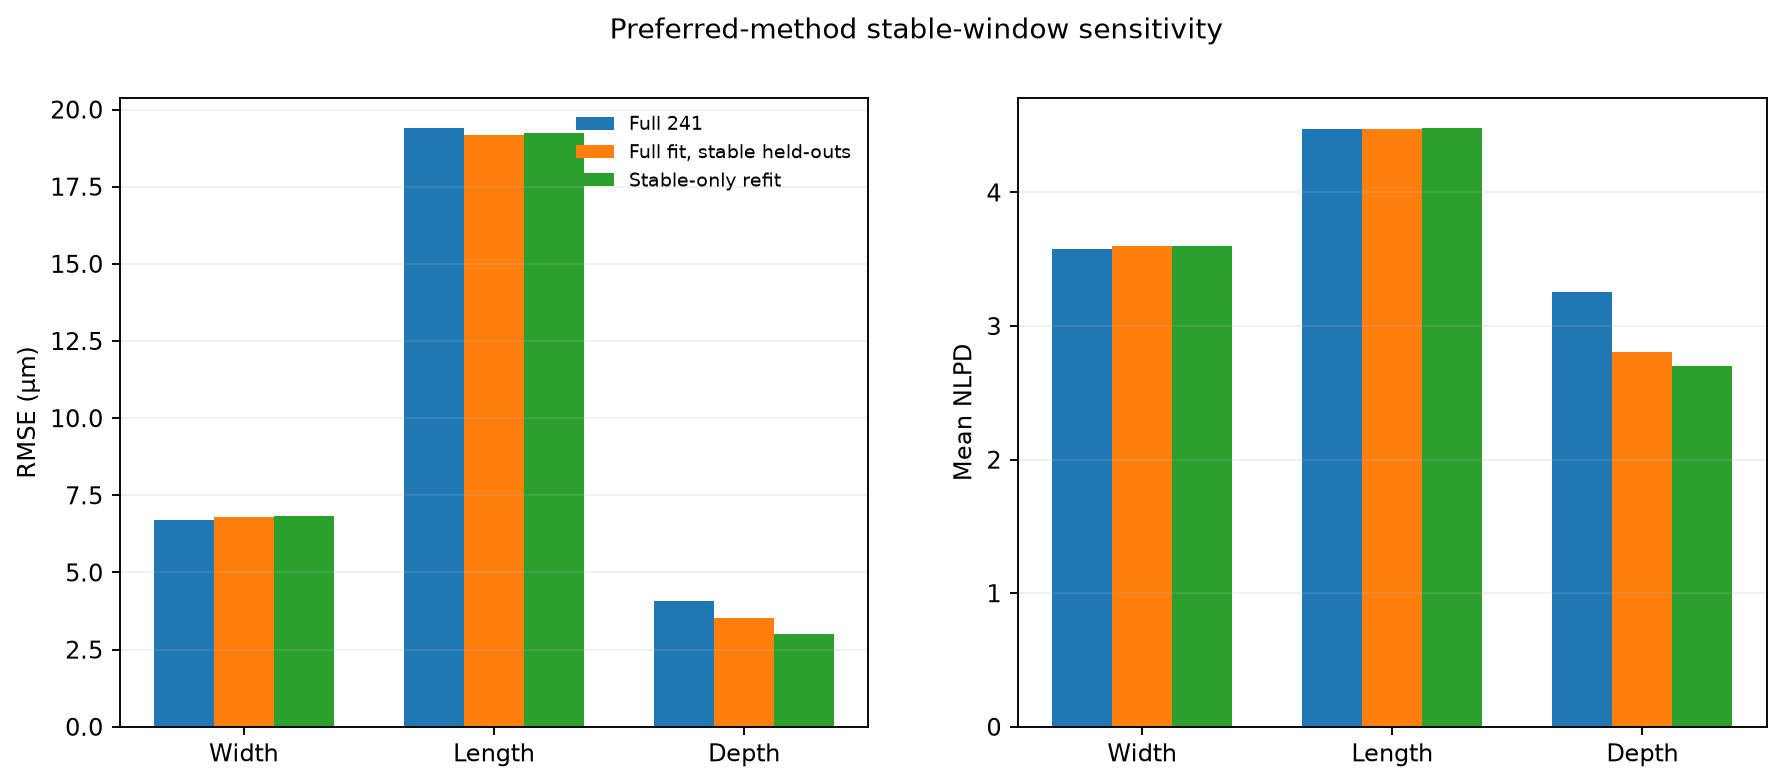

In [15]:
for filename in [
    "point_metric_comparison.png",
    "nlpd_and_coverage_comparison.png",
    "learned_nugget_distributions.png",
    "observation_specific_uncertainty_distributions.png",
    "target_uncertainty_vs_unstable_flag.png",
    "stable_subset_sensitivity.png",
]:
    print(filename)
    display(Image(filename=str(OUT / filename)))

Separate focused figures cover point error, predictive density and
calibration, learned nugget behavior, observation-specific
uncertainty, the Phase 1 flag, and stable-only refitting. Additional
target-specific observed/predicted, residual, interval, and paired
difference figures are saved in the output directory.

## 15. Automated validation

In [16]:
validation = pd.read_csv(OUT / "validation_results.csv")
display(validation)
non_notebook = validation.loc[
    validation["validation_check"]
    != "notebook has zero error outputs"
]
assert non_notebook["status"].eq("PASS").all()
print(
    "recorded validation:",
    validation["status"].value_counts().to_dict(),
)

,validation_number,validation_check,status,passed,details
0,1,exactly 241 unique simulation rows,PASS,True,"rows=241, unique=241"
1,2,"X contains exactly P, VX, LS, ST",PASS,True,"[""P"",""VX"",""LS"",""ST""]"
2,3,no target-derived feature leakage,PASS,True,every fold records the four allowed feature na...
3,4,three finite positive targets in micrometres,PASS,True,target cells checked=723
4,5,fold-local X scaling,PASS,True,2859 fold scalers independently recomputed
5,6,fold-local y scaling,PASS,True,2859 fold scalers independently recomputed
6,7,held-out target never used for scaling or opti...,PASS,True,2859 fold scalers independently recomputed
7,8,exactly 241 predictions per target and method,PASS,True,"nine primary groups, each with 241 rows"
8,9,no duplicate held-out predictions,PASS,True,unique simulation ID within every target-metho...
9,10,finite predictive means,PASS,True,primary and stable-only predictions checked


recorded validation: {'PASS': 24}


The validator independently recomputes fold-local scalers, metrics,
NLPD, interval ordering, paired alignment, Phase 1 hashes, and both
worktree protections. During the first notebook execution its own
cleanliness check is necessarily pending; validation is refreshed
after the executed notebook is saved.

## 16. Conclusion and boundary

The accepted treatment for each target is a predictive modelling
choice under a fixed MatÃ©rn 3/2 family. It does not establish
causality, feature importance, simulator stochasticity, or a
deployable oracle interval. Later feature-effect analysis may use
the validated response-specific preferences; active learning and
level-set estimation remain unstarted.